## Krylov quantum diagonalization on a quantum computer

We will now implement Krylov quantum diagonalization on a real quantum computer. Let's start by importing some useful packages.



In [1]:
import numpy as np
import scipy as sp
import matplotlib.pylab as plt
from typing import Union, List
import warnings

from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter

from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeAuckland

import itertools as it

warnings.filterwarnings("ignore")


We define the function below to solve the generalized eigenvalue problem we just explained above.



In [2]:
def solve_regularized_gen_eig(
    h: np.ndarray,
    s: np.ndarray,
    threshold: float,
    k: int = 1,
    return_dimn: bool = False,
) -> Union[float, List[float]]:
    """
    Method for solving the generalized eigenvalue problem with regularization

    Args:
        h (numpy.ndarray):
            The effective representation of the matrix in our Krylov subspace
        s (numpy.ndarray):
            The matrix of overlaps between vectors of our Krylov subspace
        threshold (float):
            Cut-off value for the eigenvalue of s
        k (int):
            Number of eigenvalues to return
        return_dimn (bool):
            Whether to return the size of the regularized subspace

    Returns:
        lowest k-eigenvalue(s) that are the solution of the regularized generalized eigenvalue problem


    """
    s_vals, s_vecs = sp.linalg.eigh(s)
    s_vecs = s_vecs.T
    good_vecs = np.array([vec for val, vec in zip(s_vals, s_vecs) if val > threshold])
    h_reg = good_vecs.conj() @ h @ good_vecs.T
    s_reg = good_vecs.conj() @ s @ good_vecs.T
    if k == 1:
        if return_dimn:
            return sp.linalg.eigh(h_reg, s_reg)[0][0], len(good_vecs)
        else:
            return sp.linalg.eigh(h_reg, s_reg)[0][0]
    else:
        if return_dimn:
            return sp.linalg.eigh(h_reg, s_reg)[0][:k], len(good_vecs)
        else:
            return sp.linalg.eigh(h_reg, s_reg)[0][:k]

At least in initial benchmarking, it is useful to know an exact classical solution to check convergence behavior. The function below calculates the ground state energy of a Hamiltonian, using the Hamiltonian and the number of qubits as arguments.



In [3]:
def single_particle_gs(H_op, n_qubits):
    """
    Find the ground state of the single particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    print("n_sys_qubits", n_qubits)

    n_exc = 1
    sub_dimn = int(sp.special.comb(n_qubits + 1, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    few_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits + 1), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states

    m = 0
    for i, i_set in enumerate(sparse_vecs):
        for j, j_set in enumerate(sparse_vecs):
            m += 1

            if len(i_set.symmetric_difference(j_set)) <= 2:
                for p_x, p_z, coeff in zip(H_x, H_z, H_c):
                    if i_set.symmetric_difference(j_set) == p_x:
                        sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                    else:
                        sgn = 0

                    few_particle_H[i, j] += sgn * coeff

    gs_en = min(np.linalg.eigvalsh(few_particle_H))
    print("single particle ground state energy: ", gs_en)
    return gs_en

### Step 1: Map problem to quantum circuits and operators

Now we will define a Hamiltonian. This is distinct from the function above in that the function above takes a Hamiltonian as an argument and returns only the ground state, and it does so classically. This Hamiltonian we define here determines the energy levels of all energy eigenstates, and this Hamiltonian can be constructed using Pauli operators and implemented on a quantum computer.

We choose a Hamiltonian corresponding to a chain of spins which can have any orientation in space, called a "Heisenberg chain". We assume that the $i^\text{th}$ spin can be influenced by its nearest neighbors (the $(i-1)^\text{th}$ and $(i+1)^\text{th}$ spins) but not by more distant neighbors. We also allow for the possibility that the interaction between spins is different when the spins point along different axes. This asymmetry sometimes arises, for example, due to the structure of the crystal lattice into which spins are embedded.



In [4]:
# Define problem Hamiltonian.
n_qubits = 10
# coupling strength for XX, YY, and ZZ interactions
JX = 1
JY = 3
JZ = 2

# Define the Hamiltonian:
H_int = [["I"] * n_qubits for _ in range(3 * (n_qubits - 1))]
for i in range(n_qubits - 1):
    H_int[i][i] = "Z"
    H_int[i][i + 1] = "Z"
for i in range(n_qubits - 1):
    H_int[n_qubits - 1 + i][i] = "X"
    H_int[n_qubits - 1 + i][i + 1] = "X"
for i in range(n_qubits - 1):
    H_int[2 * (n_qubits - 1) + i][i] = "Y"
    H_int[2 * (n_qubits - 1) + i][i + 1] = "Y"
H_int = ["".join(term) for term in H_int]
H_tot = [
    (term, JZ)
    if term.count("Z") == 2
    else (term, JY)
    if term.count("Y") == 2
    else (term, JX)
    for term in H_int
]

# Get operator
H_op = SparsePauliOp.from_list(H_tot)
print(H_tot)

[('ZZIIIIIIII', 2), ('IZZIIIIIII', 2), ('IIZZIIIIII', 2), ('IIIZZIIIII', 2), ('IIIIZZIIII', 2), ('IIIIIZZIII', 2), ('IIIIIIZZII', 2), ('IIIIIIIZZI', 2), ('IIIIIIIIZZ', 2), ('XXIIIIIIII', 1), ('IXXIIIIIII', 1), ('IIXXIIIIII', 1), ('IIIXXIIIII', 1), ('IIIIXXIIII', 1), ('IIIIIXXIII', 1), ('IIIIIIXXII', 1), ('IIIIIIIXXI', 1), ('IIIIIIIIXX', 1), ('YYIIIIIIII', 3), ('IYYIIIIIII', 3), ('IIYYIIIIII', 3), ('IIIYYIIIII', 3), ('IIIIYYIIII', 3), ('IIIIIYYIII', 3), ('IIIIIIYYII', 3), ('IIIIIIIYYI', 3), ('IIIIIIIIYY', 3)]


The code below restricts the Hamiltonian to single particle states, and uses the spectral norm to set a good size for our time step $dt$. We heuristically choose a value for the time-step `dt` (based on upper bounds on the Hamiltonian norm). Ref [\[9\]](#references)  showed that a sufficiently small timestep is $\pi/\vert \vert H \vert \vert$, and that it is preferable up to a point to underestimate this value rather than overestimate, since overestimating can allow contributions from high-energy states to corrupt even the optimal state in the Krylov space. On the other hand, choosing $dt$ to be too small leads to worse conditioning of the Krylov subspace, since the Krylov basis vectors differ less from timestep to timestep.



In [5]:
# Get Hamiltonian restricted to single-particle states
single_particle_H = np.zeros((n_qubits, n_qubits))
for i in range(n_qubits):
    for j in range(i + 1):
        for p, coeff in H_op.to_list():
            p_x = Pauli(p).x
            p_z = Pauli(p).z
            if all(p_x[k] == ((i == k) + (j == k)) % 2 for k in range(n_qubits)):
                sgn = ((-1j) ** sum(p_z[k] and p_x[k] for k in range(n_qubits))) * (
                    (-1) ** p_z[i]
                )
            else:
                sgn = 0
            single_particle_H[i, j] += sgn * coeff
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        single_particle_H[i, j] = np.conj(single_particle_H[j, i])

# Set dt according to spectral norm
dt = np.pi / np.linalg.norm(single_particle_H, ord=2)
dt

np.float64(0.17453292519943295)

We specify the number of Trotter steps to use in the time evolution. We also specify a maximum Krylov dimension of 4. This Krylov dimension is not large enough for realistic applications. But it is sufficient for this example. Furthermore, we will check for convergence at even smaller dimensions. We will explore methods in later lessons that allow us to scale and project our Hamiltonians onto larger subspaces.



In [6]:
# Set parameters for quantum Krylov algorithm
krylov_dim = 4  # size of krylov subspace
num_trotter_steps = 4
dt_circ = dt / num_trotter_steps

#### State preparation

Pick a reference state $\vert \psi \rangle$ that has some overlap with the ground state. For this Hamiltonian, We use the a state with an excitation in the middle qubit $\vert 00..010...00 \rangle$ as our reference state.



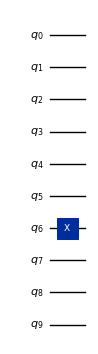

In [7]:
qc_state_prep = QuantumCircuit(n_qubits)
qc_state_prep.x(int(n_qubits / 2) + 1)
qc_state_prep.draw("mpl", scale=0.5)

#### Time evolution

We can realize the time-evolution operator generated by a given Hamiltonian: $U=e^{-iHt}$ via the [Lie-Trotter approximation](/docs/api/qiskit/qiskit.synthesis.LieTrotter). For simplicity we use the built-in `PauliEvolutionGate` in the time-evolution circuit. The general syntax for this is this.



In [8]:
t = Parameter("t")

## Create the time-evo op circuit
evol_gate = PauliEvolutionGate(
    H_op, time=t, synthesis=LieTrotter(reps=num_trotter_steps)
)

qr = QuantumRegister(n_qubits)
qc_evol = QuantumCircuit(qr)
qc_evol.append(evol_gate, qargs=qr)

We will use a version of this below in the Hadamard test, but stepping forward for times $dt$.



#### Hadamard test

Recall that we wish to calculate the matrix elements of both $\tilde{H}$ and the Gram matrix $\tilde{S}$ using the Hadamard test. Let's review how this works in this context, focusing first on the construction of $\tilde{H}.$ The overall process is depicted graphically below. The layers of colored state preparation blocks $\text{Prep}|\psi_i\rangle$ serve as a reminder that this process is carried out for all combinations of $|\psi_i\rangle$ and $|\psi_j\rangle$ in our subspace.

![An image of a quantum circuit diagram with many layers indicating that the circuit must be evaluated for many different states in order to perform the Hadamard test.](https://quantum.cloud.ibm.com/learning/images/courses/quantum-diagonalization-algorithms/krylov/kqd-fig5.avif)

The states of the system at the steps indicated are:

$$
\begin{aligned}
    \text{Step 0:}\qquad|\Psi\rangle & = |0\rangle|0\rangle^N \\
    \text{Step 1:}\qquad|\Psi\rangle & = \frac{1}{\sqrt{2}}\Big(|0\rangle + |1\rangle \Big)|0\rangle^N \\
    \text{Step 2:}\qquad|\Psi\rangle & = \frac{1}{\sqrt{2}}\Big(|0\rangle|0\rangle^N+|1\rangle |\psi_i\rangle\Big)\\
    \text{Step 3:}\qquad|\Psi\rangle & = \frac{1}{\sqrt{2}}\Big(|0\rangle |0\rangle^N+|1\rangle P |\psi_i\rangle\Big) \\
    \text{Step 4:}\qquad|\Psi\rangle & = \frac{1}{\sqrt{2}}\Big(|0\rangle |\psi_j\rangle+|1\rangle P|\psi_i\rangle\Big)
\end{aligned}
$$

Here $P$ is a Pauli term in the decomposition of the Hamiltonian (note that it cannot be a linear combination of multiple commuting Pauli terms since that would not be unitary -- grouping is possible using a different construction we will show later) $\text{Prep} \; \psi_i$, $\text{Prep} \; \psi_j$ are controlled operations that prepare $|\psi_i\rangle$, $|\psi_j\rangle$ vectors of the unitary Krylov space, with $|\psi_k\rangle = e^{-i H k dt } \vert \psi \rangle = e^{-i H k dt } U_{\psi} \vert 0 \rangle^N$. Applying measurements of $X$ and $Y$ to this circuit calculates the real and imaginary parts, respectively, of the matrix elements we require.

Starting from Step 4 above, apply the Hadamard gate $H$ to the zeroth qubit.

$$
\begin{equation*}
   |\Psi\rangle \longrightarrow\quad\frac{1}{2}|0\rangle\Big( |\psi_j\rangle + P|\psi_i\rangle\Big) + \frac{1}{2}|1\rangle\Big(|\psi_j\rangle - P|\psi_i\rangle\Big)
\end{equation*}
$$

Then measure either $X$ or $Y$.

$$
\begin{equation*}
\begin{split}
    \Rightarrow\quad\langle X\rangle &= \frac{1}{4}\Bigg(\Big\|| \psi_j\rangle + P|\psi_i\rangle \Big\|^2-\Big\||\psi_j\rangle - P|\psi_i\rangle\Big\|^2\Bigg) \\
    &= \text{Re}\Big[\langle\psi_j| P|\psi_i\rangle\Big].
\end{split}
\end{equation*}
$$

From the identity $|a + b\|^2 = \langle a + b | a + b \rangle = \|a\|^2 + \|b\|^2 + 2\text{Re}\langle a | b \rangle$. Similarly, measuring $Y$ yields

$$
\begin{equation*}
    \langle Y\rangle = \text{Im}\Big[\langle\psi_j| P|\psi_i\rangle\Big].
\end{equation*}
$$

Adding these steps to the time-evolution we set up previously we write the following.



Circuit for calculating the real part of the overlap in S via Hadamard test


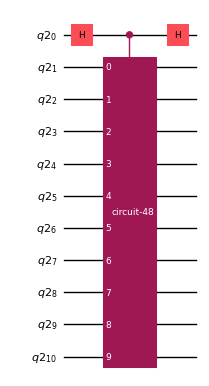

In [9]:
## Create the time-evo op circuit
evol_gate = PauliEvolutionGate(
    H_op, time=dt, synthesis=LieTrotter(reps=num_trotter_steps)
)

## Create the time-evo op dagger circuit
evol_gate_d = PauliEvolutionGate(
    H_op, time=dt, synthesis=LieTrotter(reps=num_trotter_steps)
)
evol_gate_d = evol_gate_d.inverse()

# Put pieces together
qc_reg = QuantumRegister(n_qubits)
qc_temp = QuantumCircuit(qc_reg)
qc_temp.compose(qc_state_prep, inplace=True)
for _ in range(num_trotter_steps):
    qc_temp.append(evol_gate, qargs=qc_reg)
for _ in range(num_trotter_steps):
    qc_temp.append(evol_gate_d, qargs=qc_reg)
qc_temp.compose(qc_state_prep.inverse(), inplace=True)

# Create controlled version of the circuit
controlled_U = qc_temp.to_gate().control(1)

# Create hadamard test circuit for real part
qr = QuantumRegister(n_qubits + 1)
qc_real = QuantumCircuit(qr)
qc_real.h(0)
qc_real.append(controlled_U, list(range(n_qubits + 1)))
qc_real.h(0)

print("Circuit for calculating the real part of the overlap in S via Hadamard test")
qc_real.draw("mpl", fold=-1, scale=0.5)

We warned already about the depth involved in Trotter circuits. Performing the Hadamard test in these conditions can yield an even deeper circuit, especially once we decompose to native gates. This will increase even more if we account for the topology of the device. So before using any time on the quantum computer, it is a good idea to check the 2-qubit depth of our circuit.



In [10]:
print(
    "Number of layers of 2Q operations",
    qc_real.decompose(reps=2).depth(lambda x: x[0].num_qubits == 2),
)

Number of layers of 2Q operations 14401


A circuit of this depth cannot return usable results on modern quantum computers. If we are to construct $\tilde{H}$ and $\tilde{S},$ we need a better way. This is the reason for the efficient Hadamard test introduced below.



### Step 2. Optimize circuits and operators for target hardware

#### Efficient Hadamard test

We can optimize the deep circuits for the Hadamard test that we have obtained by introducing some approximations and relying on some assumption about the model Hamiltonian. For example, consider the following circuit for the Hadamard test:

![An image of a quantum circuit diagram with many layers indicating that the circuit must be evaluated for many different unitary operators in order to perform the modified, efficient Hadamard test.](https://quantum.cloud.ibm.com/learning/images/courses/quantum-diagonalization-algorithms/krylov/kqd-fig6.avif)

Assume we can classically calculate $E_0$, the eigenvalue of $|0\rangle^N$ under the Hamiltonian $H$.
This is satisfied when the Hamiltonian preserves the U(1) symmetry. Although this may seem like a strong assumption, there are many cases where it is safe to assume that there is a vacuum state (in this case it maps to the $|0\rangle^N$ state) which is unaffected by the action of the Hamiltonian. This is true for example for chemistry Hamiltonians that describe stable molecule (where the number of electrons is conserved).
Given that the gate $\text{Prep} \; \psi_0$, prepares the desired reference state $\ket{\psi_0} = \text{Prep} \; \psi_0 \ket{0} = e^{-i H 0 dt} U_{\psi_0} \ket{0}$, for example, to prepare the HF state for chemistry $\text{Prep} \; \psi_0$ would be a product of single-qubit NOTs, so controlled-$\text{Prep} \; \psi_0$ is just a product of CNOTs.
Then the circuit above implements the following state prior to measurement:

$$
\begin{aligned}
    \text{Step 0:}\qquad|\Psi\rangle & = \ket{0} \ket{0}^{N}\\
    \text{Step 1:}\qquad|\Psi\rangle & = \frac{1}{\sqrt{2}}\left(\ket{0}\ket{0}^N+ \ket{1} \ket{0}^N\right)\\
    \text{Step 2:}\qquad|\Psi\rangle & = \frac{1}{\sqrt{2}}\left(|0\rangle|0\rangle^N+|1\rangle|\psi_0\rangle\right)\\
    \text{Step 3:}\qquad|\Psi\rangle & = \frac{1}{\sqrt{2}}\left(e^{i\phi}\ket{0}\ket{0}^N+\ket{1} U\ket{\psi_0}\right)\\
    \text{Step 4:}\qquad|\Psi\rangle & = \frac{1}{\sqrt{2}}\left(e^{i\phi}\ket{0} \ket{\psi_0}+\ket{1} U\ket{\psi_0}\right)\\
    & = \frac{1}{2}\left(\ket{+}\left(e^{i\phi}\ket{\psi_0}+U\ket{\psi_0}\right)+\ket{-}\left(e^{i\phi}\ket{\psi_0}-U\ket{\psi_0}\right)\right)\\
    & = \frac{1}{2}\left(\ket{+i}\left(e^{i\phi}\ket{\psi_0}-iU\ket{\psi_0}\right)+\ket{-i}\left(e^{i\phi}\ket{\psi_0}+iU\ket{\psi_0}\right)\right)
\end{aligned}
$$

where we have used the classical simulable phase shift $ U\ket{0}^N = e^{i\phi}\ket{0}^N$ from step 2 to 3. Therefore the expectation values are

$$
\begin{aligned}
    \langle X\otimes P\rangle&=\frac{1}{4}
    \Big(
    \left(e^{-i\phi}\bra{\psi_0}+\bra{\psi_0}U^\dagger\right)P\left(e^{i\phi}\ket{\psi_0}+U\ket{\psi_0}\right)
    \\
    &\qquad-\left(e^{-i\phi}\bra{\psi_0}-\bra{\psi_0}U^\dagger\right)P\left(e^{i\phi}\ket{\psi_0}-U\ket{\psi_0}\right)
    \Big)\\
    &=\text{Re}\left[e^{-i\phi}\bra{\psi_0}PU\ket{\psi_0}\right],
\end{aligned}

$$

$$

\begin{aligned}
    \langle Y\otimes P\rangle&=\frac{1}{4}
    \Big(
    \left(e^{-i\phi}\bra{\psi_0}+i\bra{\psi_0}U^\dagger\right)P\left(e^{i\phi_0}\ket{\psi_0}-iU\ket{\psi_0}\right)
    \\
    &\qquad-\left(e^{-i\phi}\bra{\psi_0}-i\bra{\psi_0}U^\dagger\right)P\left(e^{i\phi}\ket{\psi_0}+iU\ket{\psi_0}\right)
    \Big)\\
    &=\text{Im}\left[e^{-i\phi}\bra{\psi_0}PU\ket{\psi_0}\right].
\end{aligned}

$$

Using these assumptions we were able to write the expectation values of operators of interest with fewer controlled operations. In fact, we only need to implement the controlled state preparation $\text{Prep} \; \psi_0$ and not controlled time evolutions. Reframing our calculation as above will allow us to greatly reduce the depth of the resulting circuits.

Note that as a bonus, since the Pauli operator now appears as a measurement at the end of the circuit rather than as a controlled gate in the middle, it can be measured alongside other commuting Pauli operators as in the decomposition $H=\sum_{\alpha = 1}^{N_\text{GCP}}c_\alpha P_\alpha $ given above.



### Decompose time-evolution operator with Trotter decomposition

Instead of implementing the time-evolution operator exactly we can use the Trotter decomposition to implement an approximation of it. Repeating several times a certain order Trotter decomposition gives us further reduction of the error introduced from the approximation. In the following, we directly build the Trotter implementation in the most efficient way for the interaction graph of the Hamiltonian we are considering (nearest neighbor interactions only). In practice we insert Pauli rotations $R_{xx}$, $R_{yy}$, $R_{zz}$ with coupling strengths $J_x,$ $J_y,$ and $J_z$ and a parametrized angle $t$, which correspond to the approximate implementation of $e^{-i (J_x XX + J_y YY + J_z ZZ) t}$. Given the difference in definition of the Pauli rotations and the time-evolution that we are trying to implement, we'll have to use the parameter $2*dt$ to achieve a time-evolution of $dt$. Furthermore, we reverse the order of the operations for odd number of repetitions of the Trotter steps, which is functionally equivalent but allows for synthesizing adjacent operations in a single $SU(2)$ unitary. This gives a much shallower circuit than what is obtained using the generic `PauliEvolutionGate()` functionality.



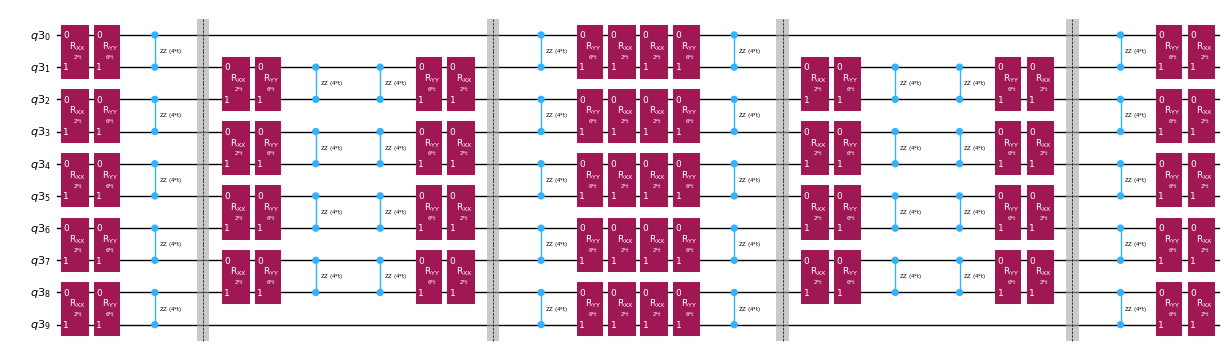

In [11]:
t = Parameter("t")

# Create instruction for rotation about XX+YY-ZZ:
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * JX * t, 0, 1)
Rxyz_circ.ryy(2 * JY * t, 0, 1)
Rxyz_circ.rzz(2 * JZ * t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="R J_x XX + J_y YY + J_z ZZ")

interaction_list = [
    [[i, i + 1] for i in range(0, n_qubits - 1, 2)],
    [[i, i + 1] for i in range(1, n_qubits - 1, 2)],
]  # linear chain

qr = QuantumRegister(n_qubits)
trotter_step_circ = QuantumCircuit(qr)
for i, color in enumerate(interaction_list):
    for interaction in color:
        trotter_step_circ.append(Rxyz_instr, interaction)
    if i < len(interaction_list) - 1:
        trotter_step_circ.barrier()
reverse_trotter_step_circ = trotter_step_circ.reverse_ops()

qc_evol = QuantumCircuit(qr)
for step in range(num_trotter_steps):
    if step % 2 == 0:
        qc_evol = qc_evol.compose(trotter_step_circ)
    else:
        qc_evol = qc_evol.compose(reverse_trotter_step_circ)

qc_evol.decompose().draw("mpl", fold=-1, scale=0.5)

We prepare an initial state again for this efficient Hadamard test.



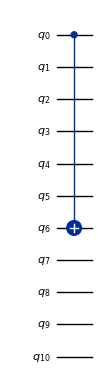

In [12]:
control = 0
excitation = int(n_qubits / 2) + 1
controlled_state_prep = QuantumCircuit(n_qubits + 1)
controlled_state_prep.cx(control, excitation)
controlled_state_prep.draw("mpl", fold=-1, scale=0.5)

#### Template circuits for calculating matrix elements of $\tilde{S}$ and $\tilde{H}$ via Hadamard test

The only difference between the circuits used in the Hadamard test will be the phase in the time-evolution operator and the observables measured. Therefore we can prepare a template circuit which represent the generic circuit for the Hadamard test, with placeholders for the gates that depend on the time-evolution operator.



In [13]:
# Parameters for the template circuits
parameters = []
for idx in range(1, krylov_dim):
    parameters.append(dt_circ * (idx))

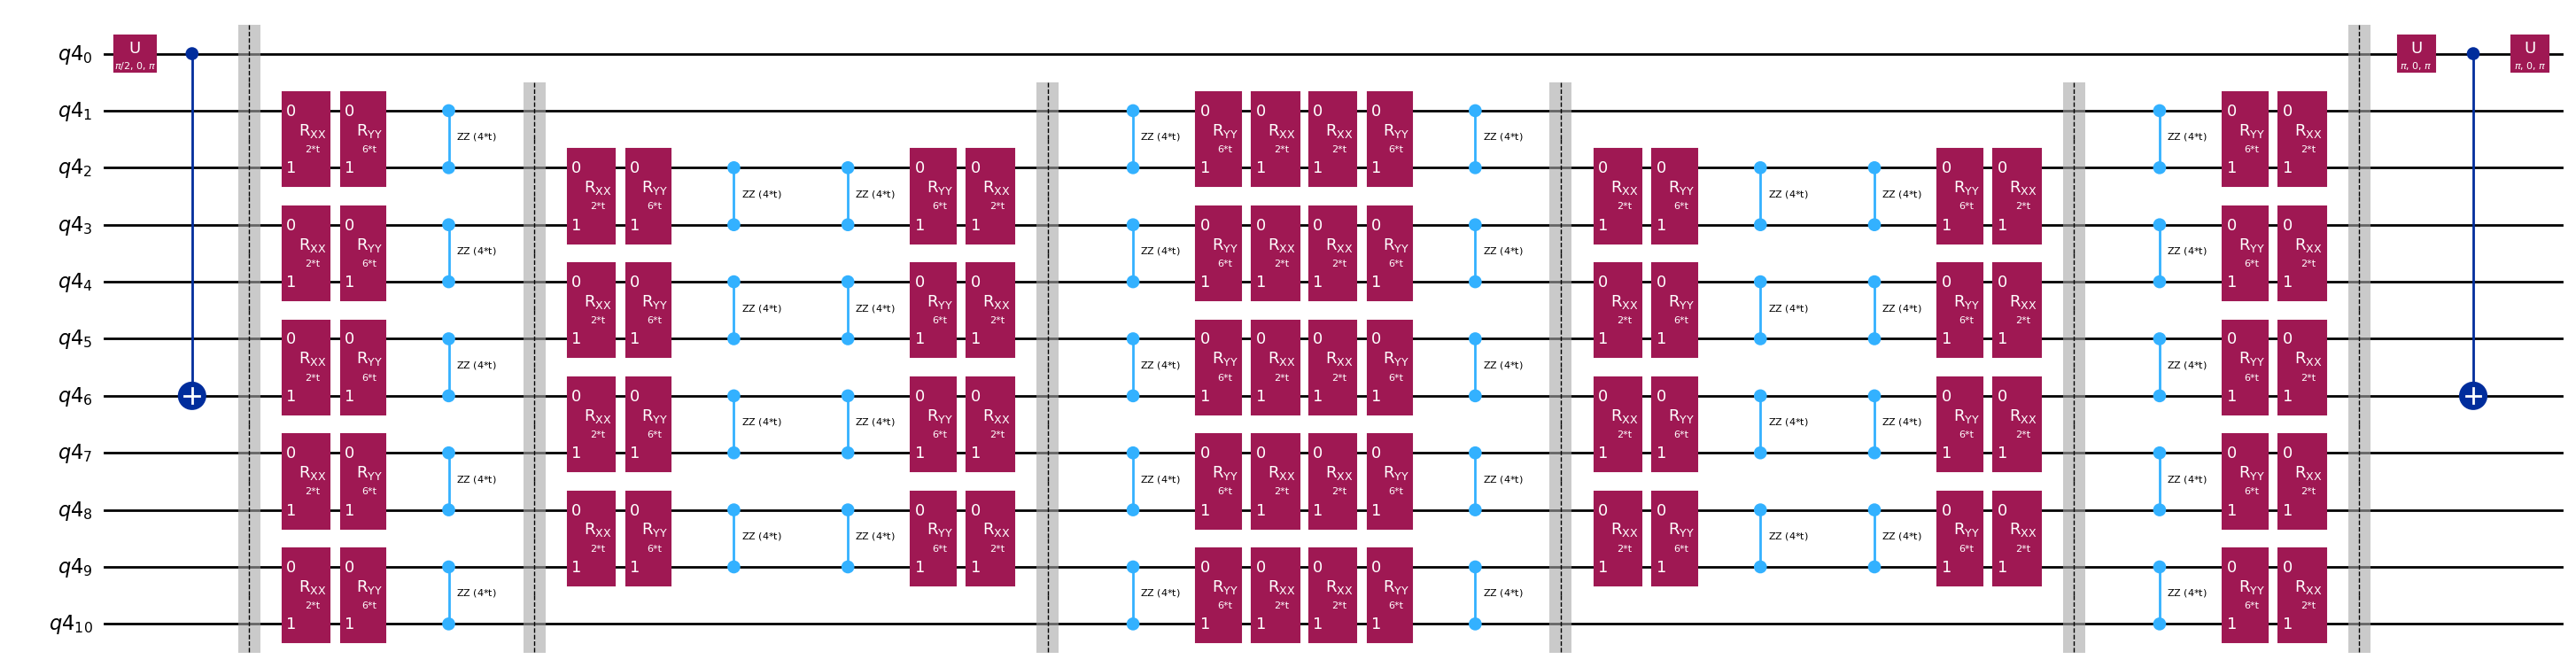

In [14]:
# Create modified hadamard test circuit
qr = QuantumRegister(n_qubits + 1)
qc = QuantumCircuit(qr)
qc.h(0)
qc.compose(controlled_state_prep, list(range(n_qubits + 1)), inplace=True)
qc.barrier()
qc.compose(qc_evol, list(range(1, n_qubits + 1)), inplace=True)
qc.barrier()
qc.x(0)
qc.compose(controlled_state_prep.inverse(), list(range(n_qubits + 1)), inplace=True)
qc.x(0)

qc.decompose().draw("mpl", fold=-1)

In [15]:
print(
    "The optimized circuit has 2Q gates depth: ",
    qc.decompose().decompose().depth(lambda x: x[0].num_qubits == 2),
)

The optimized circuit has 2Q gates depth:  50


This depth is substantially reduced compared to the original Hadamard test. This depth is manageable on modern quantum computers, though it is still quite high. We will need to use state-of-the-art error mitigation to obtain useful results.

Select a backend on which to run our quantum Krylov calculation, so that we can transpile our circuit for running on that quantum computer.



In [16]:
# Use AerSimulator with FakeAuckland noise model instead of a real QPU
backend = AerSimulator.from_backend(FakeAuckland())


We now transpile our circuits and operators.



In [17]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
basis_gates = list(target.operation_names)
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend, basis_gates=basis_gates
)

qc_trans = pm.run(qc)

36
OrderedDict({'rz': 541, 'sx': 325, 'cx': 156, 'barrier': 6, 'x': 2})


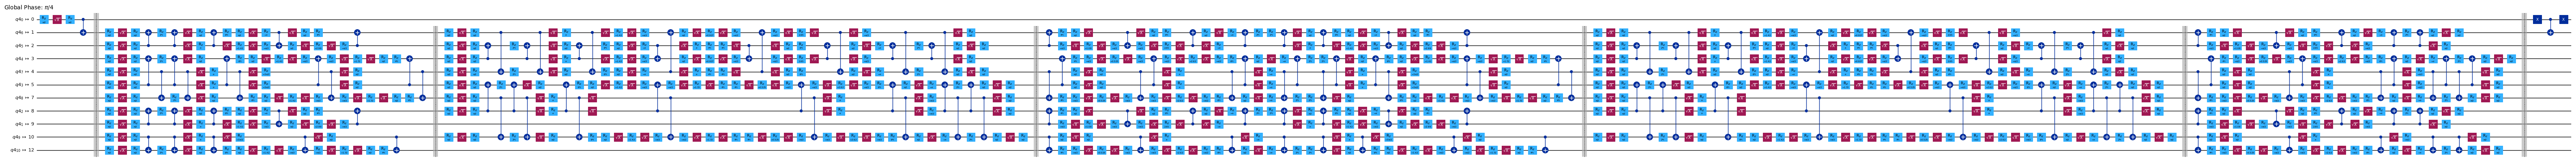

In [18]:
print(qc_trans.depth(lambda x: x[0].num_qubits == 2))
print(qc_trans.count_ops())
qc_trans.draw("mpl", fold=-1, idle_wires=False, scale=0.5)

After optimization, our transpiled two-qubit depth is further reduced.

### Step 3. Execute using a Qiskit Runtime primitive

We now create PUBs for execution with Estimator.



In [19]:
# Define observables to measure for S
observable_S_real = "I" * (n_qubits) + "X"
observable_S_imag = "I" * (n_qubits) + "Y"

observable_op_real = SparsePauliOp(
    observable_S_real
)  # define a sparse pauli operator for the observable
observable_op_imag = SparsePauliOp(observable_S_imag)

layout = qc_trans.layout  # get layout of transpiled circuit
observable_op_real = observable_op_real.apply_layout(
    layout
)  # apply physical layout to the observable
observable_op_imag = observable_op_imag.apply_layout(layout)
observable_S_real = (
    observable_op_real.paulis.to_labels()
)  # get the label of the physical observable
observable_S_imag = observable_op_imag.paulis.to_labels()

observables_S = [[observable_S_real], [observable_S_imag]]


# Define observables to measure for H
# Hamiltonian terms to measure
observable_list = []
for pauli, coeff in zip(H_op.paulis, H_op.coeffs):
    # print(pauli)
    observable_H_real = pauli[::-1].to_label() + "X"
    observable_H_imag = pauli[::-1].to_label() + "Y"
    observable_list.append([observable_H_real])
    observable_list.append([observable_H_imag])

layout = qc_trans.layout

observable_trans_list = []
for observable in observable_list:
    observable_op = SparsePauliOp(observable)
    observable_op = observable_op.apply_layout(layout)
    observable_trans_list.append([observable_op.paulis.to_labels()])

observables_H = observable_trans_list


# Define a sweep over parameter values
params = np.vstack(parameters).T


# Estimate the expectation value for all combinations of
# observables and parameter values, where the pub result will have
# shape (# observables, # parameter values).
pub = (qc_trans, observables_S + observables_H, params)

Circuits for $t=0$ are classically calculable. We carry this out before moving on to the $t\neq 0$ case using a quantum computer.



In [20]:
from qiskit.quantum_info import StabilizerState, Pauli


qc_cliff = qc.assign_parameters({t: 0})


# Get expectation values from experiment
S_expval_real = StabilizerState(qc_cliff).expectation_value(
    Pauli("I" * (n_qubits) + "X")
)
S_expval_imag = StabilizerState(qc_cliff).expectation_value(
    Pauli("I" * (n_qubits) + "Y")
)

# Get expectation values
S_expval = S_expval_real + 1j * S_expval_imag

H_expval = 0
for obs_idx, (pauli, coeff) in enumerate(zip(H_op.paulis, H_op.coeffs)):
    # Get expectation values from experiment
    expval_real = StabilizerState(qc_cliff).expectation_value(
        Pauli(pauli[::-1].to_label() + "X")
    )
    expval_imag = StabilizerState(qc_cliff).expectation_value(
        Pauli(pauli[::-1].to_label() + "Y")
    )
    expval = expval_real + 1j * expval_imag

    # Fill-in matrix elements
    H_expval += coeff * expval


print(H_expval)

(10+0j)


Although we were able to reduce our gate depth by orders of magnitude using the efficient Hadamard test, the depth is still sufficient to require state-of-the-art error mitigation. Below, we specify attributes of the mitigation being used. All of the methods used are important, but it is worth called out [probabilistic error amplification (PEA)](/docs/guides/error-mitigation-and-suppression-techniques#probabilistic-error-amplification-pea) specifically. This powerful technique comes with a great deal of quantum overhead. The calculation done here can take 20 minutes or more to run on a real quantum computer. You may wish to play with the parameters below to increase or decrease precision and consequentially overhead. The default settings below yield high-fidelity results.



In [21]:
# Simplified options for AerSimulator (no QPU-specific error mitigation needed)
options = {
    "default_shots": 4096,
}


Finally, we execute the circuits for $\tilde{S}$ and $\tilde{H}$ with Estimator.



In [22]:
# Run using AerSimulator-backed Estimator (no QPU or Batch needed)
estimator = Estimator(mode=backend)
estimator.options.default_shots = 4096

job = estimator.run([pub])


### Step 4. Post-process and analyze results

What we have obtained from the quantum computer are the individual matrix elements of $\tilde{S}$ and the commuting Pauli groups that make up the matrix elements of $\tilde{H}$. These terms must be combined to recover our matrices, so that we can solve the generalized eigenvalue problem.



In [23]:
# Store the outputs as 'results'.
results = job.result()[0]

#### Calculate Effective Hamiltonian and Overlap matrices

First calculate the phase accumulated by the $\vert 0 \rangle$ state during the uncontrolled time evolution



In [24]:
prefactors = [
    np.exp(-1j * sum([c for p, c in H_op.to_list() if "Z" in p]) * i * dt)
    for i in range(1, krylov_dim)
]

Once we have the results of the circuit executions we can post-process the data to calculate the matrix elements of $S$



In [25]:
# Assemble S, the overlap matrix of dimension D:
S_first_row = np.zeros(krylov_dim, dtype=complex)
S_first_row[0] = 1 + 0j

# Add in ancilla-only measurements:
for i in range(krylov_dim - 1):
    # Get expectation values from AerSimulator
    evs_S_real = results.data.evs[0]
    evs_S_imag = results.data.evs[1]
    # Handle both (num_params,) and (1, num_params) shapes
    if evs_S_real.ndim == 2:
        expval_real = evs_S_real[0][i]
        expval_imag = evs_S_imag[0][i]
    else:
        expval_real = evs_S_real[i]
        expval_imag = evs_S_imag[i]

    expval = expval_real + 1j * expval_imag
    S_first_row[i + 1] += prefactors[i] * expval

S_first_row_list = S_first_row.tolist()  # for saving purposes


S_circ = np.zeros((krylov_dim, krylov_dim), dtype=complex)

# Distribute entries from first row across matrix:
for i, j in it.product(range(krylov_dim), repeat=2):
    if i >= j:
        S_circ[j, i] = S_first_row[i - j]
    else:
        S_circ[j, i] = np.conj(S_first_row[j - i])


In [26]:
from sympy import Matrix

Matrix(S_circ)

Matrix([
[                             1.0, -0.02392578125 - 0.18603515625*I,     0.10546875 - 0.03662109375*I,    0.0654296875 - 0.0869140625*I],
[-0.02392578125 + 0.18603515625*I,                              1.0, -0.02392578125 - 0.18603515625*I,     0.10546875 - 0.03662109375*I],
[    0.10546875 + 0.03662109375*I, -0.02392578125 + 0.18603515625*I,                              1.0, -0.02392578125 - 0.18603515625*I],
[   0.0654296875 + 0.0869140625*I,     0.10546875 + 0.03662109375*I, -0.02392578125 + 0.18603515625*I,                              1.0]])

And the matrix elements of $\tilde{H}$



In [27]:
import itertools

# Assemble H, the effective Hamiltonian matrix of dimension D:
H_first_row = np.zeros(krylov_dim, dtype=complex)
H_first_row[0] = H_expval

for obs_idx, (pauli, coeff) in enumerate(zip(H_op.paulis, H_op.coeffs)):
    # Add in ancilla-only measurements:
    for i in range(krylov_dim - 1):
        evs_real = results.data.evs[2 + 2 * obs_idx]
        evs_imag = results.data.evs[2 + 2 * obs_idx + 1]
        # Handle both (num_params,) and (1, num_params) shapes
        if evs_real.ndim == 2:
            expval_real = evs_real[0][i]
            expval_imag = evs_imag[0][i]
        else:
            expval_real = evs_real[i]
            expval_imag = evs_imag[i]

        expval = expval_real + 1j * expval_imag
        H_first_row[i + 1] += prefactors[i] * coeff * expval

H_first_row_list = H_first_row.tolist()

H_eff_circ = np.zeros((krylov_dim, krylov_dim), dtype=complex)

# Distribute entries from first row across matrix:
for i, j in itertools.product(range(krylov_dim), repeat=2):
    if i >= j:
        H_eff_circ[j, i] = H_first_row[i - j]
    else:
        H_eff_circ[j, i] = np.conj(H_first_row[j - i])


In [28]:
from sympy import Matrix

Matrix(H_eff_circ)

Matrix([
[                              10.0, -2.181640625 - 0.30126953125*I, -0.06884765625 - 0.373046875*I, 0.240234375 - 0.0405273437499999*I],
[    -2.181640625 + 0.30126953125*I,                           10.0, -2.181640625 - 0.30126953125*I,     -0.06884765625 - 0.373046875*I],
[    -0.06884765625 + 0.373046875*I, -2.181640625 + 0.30126953125*I,                           10.0,     -2.181640625 - 0.30126953125*I],
[0.240234375 + 0.0405273437499999*I, -0.06884765625 + 0.373046875*I, -2.181640625 + 0.30126953125*I,                               10.0]])

Finally, we can solve the generalized eigenvalue problem for $\tilde{H}$:

$\tilde{H} \vec{c} = c S \vec{c}$

and get an estimate of the ground state energy $c_{min}$



In [29]:
gnd_en_circ_est_list = []
for d in range(1, krylov_dim + 1):
    # Solve generalized eigenvalue problem
    gnd_en_circ_est = solve_regularized_gen_eig(
        H_eff_circ[:d, :d], S_circ[:d, :d], threshold=1e-1
    )
    gnd_en_circ_est_list.append(gnd_en_circ_est)
    print("The estimated ground state energy is: ", gnd_en_circ_est)

The estimated ground state energy is:  10.0
The estimated ground state energy is:  7.704212101161081
The estimated ground state energy is:  6.585039352667497
The estimated ground state energy is:  5.854849577739219


For a single-particle sector, we can efficiently calculate the ground state of this sector of the Hamiltonian classically



In [30]:
gs_en = single_particle_gs(H_op, n_qubits)

n_sys_qubits 10
n_exc 1 , subspace dimension 11
single particle ground state energy:  2.39154786963877


In [31]:
len(H_op)

27

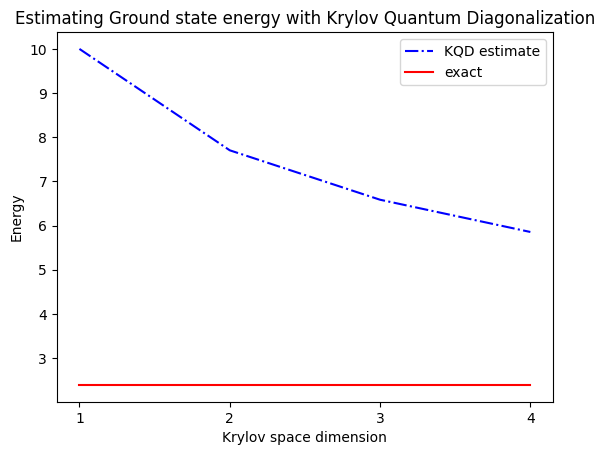

In [32]:
plt.plot(
    range(1, krylov_dim + 1),
    gnd_en_circ_est_list,
    color="blue",
    linestyle="-.",
    label="KQD estimate",
)
plt.plot(
    range(1, krylov_dim + 1),
    [gs_en] * krylov_dim,
    color="red",
    linestyle="-",
    label="exact",
)
plt.xticks(range(1, krylov_dim + 1), range(1, krylov_dim + 1))
plt.legend()
plt.xlabel("Krylov space dimension")
plt.ylabel("Energy")
plt.title("Estimating Ground state energy with Krylov Quantum Diagonalization")
plt.show()

## Discussion and extension

To recap, we start with a reference state, then evolve it for different periods of time to generate the unitary Krylov subspace. We project our Hamiltonian onto that subspace. We also estimate the overlaps of the subspace vectors. Finally we solve the lower-dimensional, generalized eigenvalue problem classically.

![A flow-chart overview of QKD: start with a reference state, evolve the state to approximate Krylov vectors, project into the Krylov subspace, diagonalize the projected subspace classically, and determine ground state properties.](https://quantum.cloud.ibm.com/learning/images/courses/quantum-diagonalization-algorithms/krylov/kqd-fig7.avif)

Let’s compare what determines computational costs of using the Krylov technique classically and quantum mechanically. There are not perfect analogs between classical and quantum approaches for all steps. This table collects some scaling of different steps for consideration.

![A table describing scaling of different processes classically and in the quantum approach to Krylov methods. Some quantum steps have no analog. The scalings are the same as those stated in text.](https://quantum.cloud.ibm.com/learning/images/courses/quantum-diagonalization-algorithms/krylov/kqd-fig8.avif)

Recall that Hamiltonians generally have terms that cannot be simultaneously measured (because they do not commute with on another). We sort terms in the Hamiltonian into groups of commuting Pauli operators that can all be measured simultaneously, and we may require many such groups to account for all the terms that do not commute with one another. To build up $\tilde{H}$ on a quantum computer requires separate measurements for each group of commuting Pauli strings in the Hamiltonian, and each of those requires many shots. We must do this for $r^2$ different matrix elements, corresponding to $r^2$ combinations of different time evolution factors. There are sometimes ways to reduce this, but in this rough treatment, the time required for this scales like $N_\text{shots}\times N_\text{GCP} \times r^2.$ The elements of $S$ must be estimated, which scales like $O(N_\text{shots}\times r^2)$. Finally, solving the generalized eigenvalue problem in the projected space, classically, takes $O(r^3).$

We see that quantum Krylov diagonalization may be useful in cases where the number of commuting Pauli groups in the Hamiltonian is relatively small. These scaling dependencies suggest some applications where the Krylov method can be useful, and others where it likely will not be.
Some Hamiltonians have high complexity when mapped to qubits, involving many non-commuting Pauli strings that cannot easily be partitioned into a few commuting groups. This is often true of quantum chemistry problems, for example. This complexity presents two primary challenges for near-term quantum computers:

* The estimation of each element of $\tilde{H}$ becomes computationally expensive due to the large number of terms.
* The required Trotter circuits become prohibitively deep.

Both of the above points will be less problematic when quantum computers reach fault-tolerance, but they must be considered in the near term. Even systems with “simpler” mappings than those in quantum chemistry may experience the same impediments, if the Hamiltonians have too many non-commuting terms.
The Krylov method is most useful where the Hamiltonian can be partitioned into relatively few commuting Pauli groups, and where $H$ is easy to implement in trotter circuits. Both of these conditions are satisfied, for example, for many lattice models of interest in physics. KQD is especially useful if very little is known about the ground state. This stems from its inherent convergence guarantees and its applicability in scenarios where alternative methods are untenable due to insufficient ground state knowledge.

While KQD is a powerful tool, the protocol's time-consuming aspects, particularly the estimation of each element of the projected Hamiltonian and the overlap of Krylov states, represent opportunities for improvement. An alternative approach involves leveraging Krylov methods in conjunction with sampling-based methods, which are the subject of the next lesson.



## 6. Appendices

### Appendix I: Krylov subspace from real time-evolutions

The unitary Krylov space is defined as

$$
\mathcal{K}_U(H, |\psi\rangle) = \text{span}\left\{ |\psi\rangle,  e^{-iH\,dt} |\psi\rangle, \dots, e^{-irH\,dt} |\psi\rangle \right\}
$$

for some timestep $dt$ that we will determine later. Temporarily assume $r$ is even: then define $d=r/2$. Notice that when we project the Hamiltonian into the Krylov space above, it is indistinguishable from the Krylov space

$$
\mathcal{K}_U(H, |\psi\rangle) = \text{span}\left\{ e^{i\,d\,H\,dt}|\psi\rangle,  e^{i(d-1)H\,dt} |\psi\rangle, \dots, e^{-i(d-1)H\,dt} |\psi\rangle, e^{-i\,d\,H\,dt} |\psi\rangle \right\},
$$

that is, where all the time-evolutions are shifted backward by $d$ timesteps.
The reason it is indistinguishable is because the matrix elements

$$
\tilde{H}_{j,k} = \langle\psi|e^{i\,j\,H\,dt}He^{-i\,k\,H\,dt}|\psi\rangle=\langle\psi|He^{i(j-k)H\,dt}|\psi\rangle
$$

are invariant under overall shifts of the evolution time, since the time-evolutions commute with the Hamiltonian. For odd $r$, we can use the analysis for $r-1$.

We want to show that somewhere in this Krylov space, there is guaranteed to be a low-energy state. We do so by way of the following result, which is derived from Theorem 3.1 in [\[3\]](#references):

**Claim 1:** there exists a function $f$ such that for energies $E$ in the spectral range of the Hamiltonian (that is, between the ground state energy and the maximum energy)...

1. $f(E_0)=1$
2. $|f(E)|\le2\left(1 + \delta\right)^{-d}$ for all values of $E$ that lie $\ge\delta$ away from $E_0$, that is, it is exponentially suppressed
3. $f(E)$ is a linear combination of $e^{ijE\,dt}$ for $j=-d,-d+1,...,d-1,d$

We give a proof below, but that can be safely skipped unless one wants to understand the full, rigorous argument. For now we focus on the implications of the above claim. By property 3 above, we can see that the shifted Krylov space above contains the state $f(H)|\psi\rangle$. This is our low-energy state. To see why, write $|\psi\rangle$ in the energy eigenbasis:

$$
|\psi\rangle = \sum_{k=0}^{N}\gamma_k|E_k\rangle,
$$

where $|E_k\rangle$ is the kth energy eigenstate and $\gamma_k$ is its amplitude in the initial state $|\psi\rangle$. Expressed in terms of this, $f(H)|\psi\rangle$ is given by

$$
f(H)|\psi\rangle = \sum_{k=0}^{N}\gamma_kf(E_k)|E_k\rangle,
$$

using the fact that we can replace $H$ by $E_k$ when it acts on the eigenstate $|E_k\rangle$. The energy error of this state is therefore

$$
\text{energy error} = \frac{\langle\psi|f(H)(H-E_0)f(H)|\psi\rangle}{\langle\psi|f(H)^2|\psi\rangle}
$$

$$
= \frac{\sum_{k=0}^{N}|\gamma_k|^2f(E_k)^2(E_k-E_0)}{\sum_{k=0}^{N}|\gamma_k|^2f(E_k)^2}.
$$

To turn this into an upper bound that is easier to understand, we first separate the sum in the numerator into terms with $E_k-E_0\le\delta$ and terms with $E_k-E_0>\delta$:

$$
\text{energy error} = \frac{\sum_{E_k\le E_0+\delta}|\gamma_k|^2f(E_k)^2(E_k-E_0)}{\sum_{k=0}^{N}|\gamma_k|^2f(E_k)^2} + \frac{\sum_{E_k> E_0+\delta}|\gamma_k|^2f(E_k)^2(E_k-E_0)}{\sum_{k=0}^{N}|\gamma_k|^2f(E_k)^2}.
$$

We can upper bound the first term by $\delta$,

$$
\frac{\sum_{E_k\le E_0+\delta}|\gamma_k|^2f(E_k)^2(E_k-E_0)}{\sum_{k=0}^{N}|\gamma_k|^2f(E_k)^2} < \frac{\delta\sum_{E_k\le E_0+\delta}|\gamma_k|^2f(E_k)^2}{\sum_{k=0}^{N}|\gamma_k|^2f(E_k)^2} \le \delta,
$$

where the first step follows because $E_k-E_0\le\delta$ for every $E_k$ in the sum, and the second step follows because the sum in the numerator is a subset of the sum in the denominator. For the second term, first we lower bound the denominator by $|\gamma_0|^2$, since $f(E_0)^2=1$: adding everything back together, this gives

$$
\text{energy error} \le \delta + \frac{1}{|\gamma_0|^2}\sum_{E_k>E_0+\delta}|\gamma_k|^2f(E_k)^2(E_k-E_0).
$$

To simplify what is left, notice that for all these $E_k$, by the definition of $f$ we know that $f(E_k)^2 \le 4\left(1 + \delta\right)^{-2d}$. Additionally upper bounding $E_k-E_0<2\|H\|$ and upper bounding $\sum_{E_k>E_0+\delta}|\gamma_k|^2<1$ gives

$$
\text{energy error} \le \delta + \frac{8}{|\gamma_0|^2}\|H\|\left(1 + \delta\right)^{-2d}.
$$

This holds for any $\delta>0$, so if we set $\delta$ equal to our goal error, then the error bound above converges towards that exponentially with the Krylov dimension $2d=r$. Also note that if $\delta<E_1-E_0$ then the $\delta$ term actually goes away entirely in the above bound.

To complete the argument, we first note that the above is just the energy error of the particular state $f(H)|\psi\rangle$, rather than the energy error of the lowest energy state in the Krylov space. However, by the (Rayleigh-Ritz) variational principle, the energy error of the lowest energy state in the Krylov space is upper bounded by the energy error of any state in the Krylov space, so the above is also an upper bound on the energy error of the lowest energy state, that is, the output of the Krylov quantum diagonalization algorithm.

A similar analysis as the above can be carried out that additionally accounts for noise and the thresholding procedure discussed in the notebook. See [\[2\]](#references) and [\[4\]](#references) for this analysis.

### Appendix II: proof of Claim 1

The following is mostly derived from [\[3\]](#references), Theorem 3.1: let $0 < a < b$ and let $\Pi^*_d$ be the space of residual polynomials (polynomials whose value at 0 is 1) of degree at most $d$. The solution to

$$
\beta(a, b, d) = \min_{p \in \Pi^*_d} \max_{x \in [a, b]} |p(x)| \quad
$$

is

$$
p^*(x) = \frac{T_d\left(\frac{b + a - 2x}{b - a}\right)}{T_d\left(\frac{b + a}{b - a}\right)}, \quad
$$

and the corresponding minimal value is

$$
\beta(a, b, d) = T_d^{-1}\left(\frac{b + a}{b - a}\right).
$$

We want to convert this into a function that can be expressed naturally in terms of complex exponentials, because those are the real time-evolutions that generate the quantum Krylov space.
To do so, it is convenient to introduce the following transformation of energies within the spectral range of the Hamiltonian to numbers in the range $[0,1]$: define

$$
g(E) = \frac{1-\cos\big((E-E_0)dt\big)}{2},
$$

where $dt$ is a timestep such that $-\pi < E_0dt < E_\text{max}dt < \pi$.
Notice that $g(E_0)=0$ and $g(E)$ grows as $E$ moves away from $E_0$.

Now using the polynomial $p^*(x)$ with the parameters a, b, d set to $a = g(E_0 + \delta)$, $b = 1$, and d = int(r/2), we define the function:

$$
f(E) = p^* \left( g(E) \right) = \frac{T_d\left(1 + 2\frac{\cos\big((E-E_0)dt\big) - \cos\big(\delta\,dt\big)}{1 +\cos\big(\delta\,dt\big)}\right)}{T_d\left(1 + 2\frac{1-\cos\big(\delta\,dt\big)}{1 + \cos\big(\delta\,dt\big)}\right)}
$$

where $E_0$ is the ground state energy. We can see by inserting $\cos(x)=\frac{e^{ix}+e^{-ix}}{2}$ that $f(E)$ is a trigonometric polynomial of degree $d$, that is, a linear combination of $e^{ijE\,dt}$ for $j=-d,-d+1,...,d-1,d$. Furthermore, from the definition of $p^*(x)$ above we have that $f(E_0)=p(0)=1$ and for any $E$ in the spectral range such that $\vert E-E_0 \vert > \delta$ we have

$$
|f(E)| \le \beta(a, b, d) = T_d^{-1}\left(1 + 2\frac{1-\cos\big(\delta\,dt\big)}{1 + \cos\big(\delta\,dt\big)}\right)
$$

$$
\leq 2\left(1 + \delta\right)^{-d} = 2\left(1 + \delta\right)^{-\lfloor k/2\rfloor}.
$$



## References:

\[1] [https://arxiv.org/abs/2407.14431](https://arxiv.org/abs/2407.14431)

\[2] [https://arxiv.org/abs/1811.09025](https://arxiv.org/abs/1811.09025)

\[3] [https://people.math.ethz.ch/\~mhg/pub/biksm.pdf](https://people.math.ethz.ch/~mhg/pub/biksm.pdf)

\[4] [https://academic.oup.com/book/36426](https://academic.oup.com/book/36426)

\[5] [https://en.wikipedia.org/wiki/Krylov\_subspace](https://en.wikipedia.org/wiki/Krylov_subspace)

\[6] Krylov Subspace Methods: Principles and Analysis, Jörg Liesen, Zdenek Strakos [https://academic.oup.com/book/36426](https://academic.oup.com/book/36426)

\[7] Iterative Methods for Sparse Linear Systems" by Yousef Saad

\[8] "MINRES-QLP: A Krylov Subspace Method for Indefinite or Singular Symmetric Systems" by Sou-Cheng Choi, Christopher Paige, and
Michael Saunders ([https://epubs.siam.org/doi/10.1137/100787921](https://epubs.siam.org/doi/10.1137/100787921))

\[9] Ethan N. Epperly, Lin Lin, and Yuji Nakatsukasa. "A theory of quantum subspace diagonalization". SIAM Journal on Matrix Analysis and Applications 43, 1263–1290 (2022).

\[10] [https://link.aps.org/doi/10.1103/PRXQuantum.4.030319](https://link.aps.org/doi/10.1103/PRXQuantum.4.030319)



© IBM Corp., 2017-2026